In [1]:
!pip install --quiet --upgrade patsy statsmodels seaborn

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models, applications
from google.colab import drive

# Configure Environment
sns.set_theme(style="whitegrid")
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
drive.mount('/content/drive')
!cp -r "/content/drive/MyDrive/IML Final Project/Dataset" "/content/Local_Dataset"

Mounted at /content/drive


In [3]:
# ==========================================
# 2. Hyperparameters & Global Configuration
# ==========================================
# Standard image dimensions for EfficientNetB0
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-4

# Path to the local dataset after mounting Drive
DATASET_DIR = '/content/Local_Dataset'
TRAIN_DIR = os.path.join(DATASET_DIR, 'Training')
TEST_DIR = os.path.join(DATASET_DIR, 'Testing')

# ==========================================
# 3. Data Ingestion
# ==========================================
# Generate tf.data.Dataset objects for training and validation
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

# Extract class names for downstream reporting
class_names = train_dataset.class_names
print(f"Target Classes: {class_names}")

# ==========================================
# 4. Data Augmentation & Performance Optimization
# ==========================================
# Integrated augmentation layer for in-graph processing
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
])

# Apply performance optimizations using AUTOTUNE
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(buffer_size=AUTOTUNE)

val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

Found 5608 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
Target Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [4]:
# Pointing to the local directory where you copied your dataset
train_dir = '/content/Local_Dataset/Training' # Update if your local path differs
classes = sorted(os.listdir(train_dir))
class_counts = {}
total_samples = 0

# Count the files in each class directory
for c in classes:
    count = len(os.listdir(os.path.join(train_dir, c)))
    class_counts[c] = count
    total_samples += count

# Calculate weights: W_i = N / (C * N_i)
num_classes = len(classes)
class_weights_dict = {}

for i, c in enumerate(classes):
    weight = total_samples / (num_classes * class_counts[c])
    class_weights_dict[i] = weight

print(f"Total Samples: {total_samples}")
print(f"Class Counts: {class_counts}")
print(f"Computed Class Weights: {class_weights_dict}")

Total Samples: 5608
Class Counts: {'glioma': 1400, 'meningioma': 1400, 'notumor': 1407, 'pituitary': 1401}
Computed Class Weights: {0: 1.0014285714285713, 1: 1.0014285714285713, 2: 0.9964463397299218, 3: 1.0007137758743754}


Phase 2

In [5]:
# ==========================================
# 5. Model Architecture: Transfer Learning
# ==========================================
# Load EfficientNetB0 with ImageNet weights, excluding the classifier top
base_model = applications.EfficientNetB0(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze feature extractor weights to prevent catastrophic forgetting during initial training
base_model.trainable = False

# Construct Functional Model
inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# ==========================================
# 6. Loss Function and Compilation
# ==========================================
# Use Focal Loss to address class imbalance by down-weighting well-classified samples
focal_loss = tf.keras.losses.CategoricalFocalCrossentropy(alpha=0.25, gamma=2.0)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=focal_loss,
    metrics=['accuracy']
)

# ==========================================
# 7. Training Callbacks
# ==========================================
callbacks_list = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/IML Final Project/best_brain_tumor_model.keras",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# ==========================================
# 8. Model Training
# ==========================================
print("Executing initial training phase...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=class_weights_dict,
    callbacks=callbacks_list
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Executing initial training phase...
Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.3172 - loss: 0.2230
Epoch 1: val_accuracy improved from None to 0.63875, saving model to /content/drive/MyDrive/IML Final Project/best_brain_tumor_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/IML Final Project/best_brain_tumor_model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 123s 506ms/step - accuracy: 0.3809 - loss: 0.1934 - val_accuracy: 0.6388 - val_loss: 0.1208
Epoch 2/20
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.5339 - loss: 0.1427
Epoch 2: val_accuracy improved from 0.63875 to 0.71375, saving model to /content/drive/MyDrive/IML Final Project/best_brain_tumor_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/IML Final Project/best_brain_tumor_model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 61s 345ms/step - accuracy: 0.5704 - loss: 0.1306 - val_accuracy: 0.7138 - val_loss: 0.0954
Epoch

Phase 4

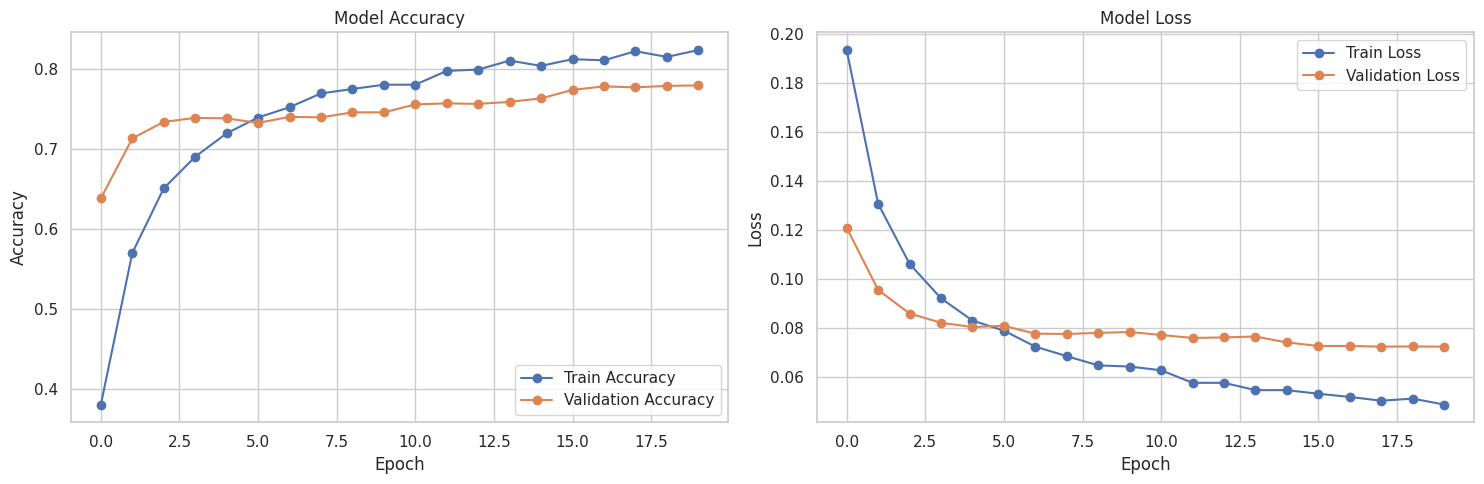


Evaluating model on the test dataset...
Test Accuracy: 0.7800
Test Loss: 0.0722

Classification Report:
              precision    recall  f1-score   support

      glioma       0.84      0.54      0.66       400
  meningioma       0.70      0.62      0.66       400
     notumor       0.88      0.97      0.92       400
   pituitary       0.72      0.99      0.84       400

    accuracy                           0.78      1600
   macro avg       0.79      0.78      0.77      1600
weighted avg       0.79      0.78      0.77      1600



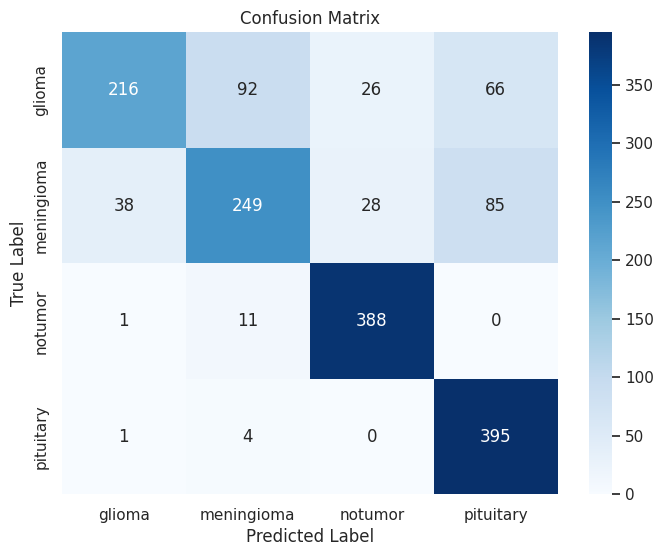

In [6]:
# ==========================================
# 9. Plotting Training Trends (Loss & Accuracy)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Set styling for the plots
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')

# Plot Loss
axes[1].plot(history.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='o')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# ==========================================
# 10. Evaluation Metrics & Confusion Matrix
# ==========================================
print("\nEvaluating model on the test dataset...")
test_loss, test_acc = model.evaluate(val_dataset, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}\n")

# Extract true labels and model predictions
y_true = []
y_pred_probs = []

# Iterate through the validation dataset
for images, labels in val_dataset:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    predictions = model.predict(images, verbose=0)
    y_pred_probs.extend(predictions)

y_true = np.array(y_true)
y_pred = np.argmax(y_pred_probs, axis=1)

# Generate Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Generate and Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Phase 5

In [7]:
import cv2
import numpy as np
import matplotlib.cm as cm

def make_gradcam_heatmap(img_array, full_model):
    """Generates a Grad-CAM heatmap for a given input image and model."""
    with tf.GradientTape() as tape:
        # Identify the convolutional base model
        base_model = next(l for l in full_model.layers if 'efficientnet' in l.name)
        conv_outputs = base_model(img_array, training=False)
        tape.watch(conv_outputs)

        # Reconstruct the forward pass through the classification head
        x = conv_outputs
        head_layers_found = False
        for layer in full_model.layers:
            if head_layers_found:
                x = layer(x, training=False)
            if layer == base_model:
                head_layers_found = True

        preds = x
        top_pred_index = tf.argmax(preds[0])
        top_class_channel = preds[:, top_pred_index]

    # Calculate gradients of the top predicted class w.r.t the last conv layer output
    grads = tape.gradient(top_class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature map by the gradient importance
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize heatmap for visualization
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, title, alpha=0.4):
    """Superimposes the Grad-CAM heatmap onto the original image."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Rescale and colorize heatmap
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Resize heatmap to match original image dimensions
    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    # Overlay heatmap on image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed_img)
    plt.title(title)
    plt.axis('off')
    plt.show()

Teating

/tmp/ipykernel_3673/312853767.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


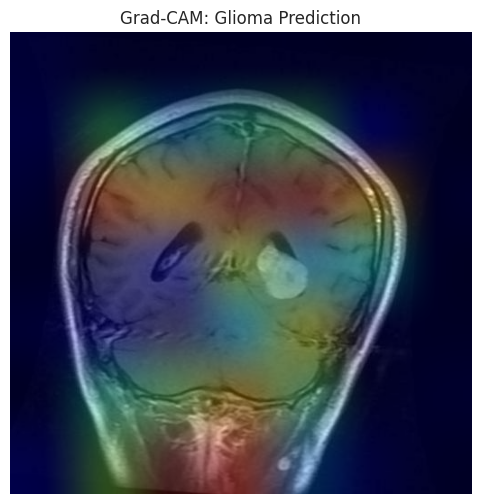

In [11]:
# ==========================================
# 12. Testing Grad-CAM on a Sample Image
# ==========================================
# TODO: Replace with the path to ANY specific image from your Testing folder
sample_image_path = f"{TEST_DIR}/meningioma/Te-aug-me_11.jpg"

# Prepare image for the model
img = tf.keras.utils.load_img(sample_image_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Generate and Display
heatmap = make_gradcam_heatmap(img_array, model)
display_gradcam(sample_image_path, heatmap, "Grad-CAM: Glioma Prediction")

Phase 6

In [17]:
import gradio as gr
import cv2
import numpy as np
import tensorflow as tf
from PIL import Image
import matplotlib.cm as cm

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

def predict_and_visualize(input_image):
    # 1. STRICT PREPROCESSING: Force the web image into a standard RGB format
    # This strips away any transparent Alpha channels from PNGs
    img_pil = Image.fromarray(np.uint8(input_image)).convert('RGB')
    img_resized = img_pil.resize((224, 224))

    # Convert to the exact float32 array expected by Keras
    img_array = tf.keras.utils.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)

    # 2. Get Model Predictions
    predictions = model.predict(img_array, verbose=0)[0]
    confidences = {class_names[i]: float(predictions[i]) for i in range(len(class_names))}

    # 3. Generate Grad-CAM Heatmap
    heatmap = make_gradcam_heatmap(img_array, model)

    # 4. Superimpose Heatmap
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((input_image.shape[1], input_image.shape[0]))
    jet_heatmap = tf.keras.utils.img_to_array(jet_heatmap)

    superimposed_img = jet_heatmap * 0.4 + input_image
    superimposed_img = tf.keras.utils.array_to_img(superimposed_img)

    return confidences, superimposed_img

# Build and launch the Gradio Web Interface
demo = gr.Interface(
    fn=predict_and_visualize,
    inputs=gr.Image(label="Upload Brain MRI"),
    outputs=[
        gr.Label(num_top_classes=4, label="AI Prediction Probabilities"),
        gr.Image(label="Grad-CAM Clinical Explainability")
    ],
    title="🧠 Brain Tumor MRI Classifier & Explainability Dashboard",
    description="Upload a raw brain MRI scan. The system will detect the presence and type of tumor while highlighting the specific anatomical regions that influenced its decision.",
    theme=gr.themes.Soft()
)

demo.launch(debug=True, share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c5f6de456cad20f033.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/tmp/ipykernel_3673/436699478.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")
/tmp/ipykernel_3673/436699478.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")
/tmp/ipykernel_3673/436699478.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")
/tmp/ipykernel_3673/436699478.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed 

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://c5f6de456cad20f033.gradio.live
